In [87]:
import numpy as np
from pandas.core.computation.ops import Constant
from sklearn.datasets import load_iris
from sklearn.linear_model import Perceptron
iris=load_iris(as_frame=True)
X=iris.data[["petal length (cm)","petal width (cm)"]].values
y=(iris.target==0)
per_clf=Perceptron(random_state=42)
per_clf.fit(X,y)
X_new=[[2,0.5],[3,2]]
y_pred=per_clf.predict(X_new)
y_pred
per_clf.coef_,per_clf.intercept_


(array([[-1.4, -2.2]]), array([4.]))

In [88]:
from sklearn.linear_model import SGDClassifier
sgd_clf=SGDClassifier(penalty=None,loss="perceptron",eta0=1,learning_rate="constant",random_state=42)
sgd_clf.fit(X,y)
sgd_clf.predict(X_new)
sgd_clf.coef_,sgd_clf.intercept_
assert (sgd_clf.coef_ == per_clf.coef_).all()
assert (sgd_clf.intercept_ == per_clf.intercept_).all()


In [89]:
x_min,x_max=X[:,0].min()-1,X[:,0].max()+1
y_min,y_max=X[:,0].min()-1,X[:,1].max()+1
x_new=np.linspace(x_min,x_max,300)
y_new=np.linspace(y_min,y_max,300)
xx,yy=np.meshgrid(x_new,y_new)
grid=np.c_[xx.ravel(),yy.ravel()]
z=per_clf.predict(grid)
z=z.reshape(xx.shape)
xx.shape

(300, 300)

<function matplotlib.pyplot.show(close=None, block=None)>

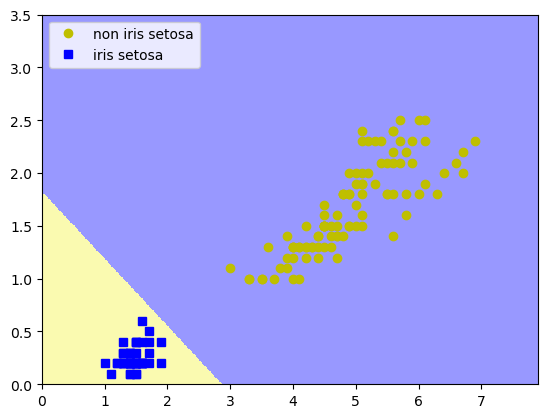

In [90]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
custom_cmap = ListedColormap(['#9898ff', '#fafab0'])
plt.contourf(xx,yy,z,alpha=1,cmap=custom_cmap)
plt.plot(X[y==0,0],X[y==0,1],"yo",label="non iris setosa")
plt.plot(X[y==1,0],X[y==1,1],"bs",label="iris setosa")
plt.legend(loc="upper left")
plt.axis()
plt.show

In [91]:
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.metrics import root_mean_squared_error
housing=fetch_california_housing()
x_train,x_test,y_train,y_test=train_test_split(housing.data,housing.target,random_state=42)
mlp_reg=MLPRegressor(hidden_layer_sizes=[50,50,50],early_stopping=True,verbose=True,solver="adam",random_state=42)
scale=StandardScaler()

In [92]:
pipeline=make_pipeline(scale,mlp_reg)
pipeline.fit(x_train,y_train)


Iteration 1, loss = 0.85190332
Validation score: 0.534299
Iteration 2, loss = 0.28288639
Validation score: 0.651094
Iteration 3, loss = 0.22884372
Validation score: 0.699782
Iteration 4, loss = 0.20746145
Validation score: 0.720468
Iteration 5, loss = 0.19649383
Validation score: 0.724839
Iteration 6, loss = 0.18928708
Validation score: 0.740084
Iteration 7, loss = 0.18132029
Validation score: 0.747406
Iteration 8, loss = 0.17556450
Validation score: 0.753945
Iteration 9, loss = 0.17190651
Validation score: 0.760500
Iteration 10, loss = 0.16687650
Validation score: 0.759213
Iteration 11, loss = 0.16329479
Validation score: 0.761907
Iteration 12, loss = 0.16054473
Validation score: 0.768950
Iteration 13, loss = 0.15690181
Validation score: 0.762699
Iteration 14, loss = 0.15630644
Validation score: 0.766003
Iteration 15, loss = 0.15712517
Validation score: 0.778464
Iteration 16, loss = 0.15155981
Validation score: 0.774237
Iteration 17, loss = 0.14957641
Validation score: 0.778361
Iterat

,steps,"[('standardscaler', ...), ('mlpregressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,loss,'squared_error'
,hidden_layer_sizes,"[50, 50, ...]"
,activation,'relu'
,solver,'adam'


In [93]:
mlp_reg.best_validation_score_

0.791536125425778

In [102]:
y_pred=pipeline.predict(x_test)
rmse=root_mean_squared_error(y_test,y_pred)
rmse

0.5327699946812925

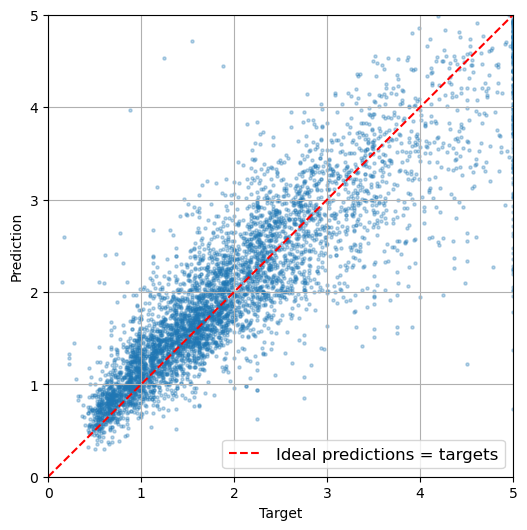

In [103]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, s=5, alpha=0.3)
plt.plot([0, 5.2], [0, 5.2], color='red', linestyle='--',
         label="Ideal predictions = targets")

plt.xlabel("Target")
plt.ylabel("Prediction")
plt.legend(fontsize=12)
plt.grid()
plt.axis([0,5,0,5])

plt.show()

(array([  4.,   9.,  46., 187., 406., 495., 418., 605., 652., 537., 612.,
        540., 627., 622., 683., 717., 596., 613., 513., 390., 467., 492.,
        427., 368., 328., 343., 342., 246., 240., 154., 173., 182., 173.,
        193., 217., 143., 130., 109.,  84., 103.,  76.,  78.,  59.,  65.,
         78.,  45.,  34.,  40.,  34., 785.]),
 array([0.14999  , 0.2469904, 0.3439908, 0.4409912, 0.5379916, 0.634992 ,
        0.7319924, 0.8289928, 0.9259932, 1.0229936, 1.119994 , 1.2169944,
        1.3139948, 1.4109952, 1.5079956, 1.604996 , 1.7019964, 1.7989968,
        1.8959972, 1.9929976, 2.089998 , 2.1869984, 2.2839988, 2.3809992,
        2.4779996, 2.575    , 2.6720004, 2.7690008, 2.8660012, 2.9630016,
        3.060002 , 3.1570024, 3.2540028, 3.3510032, 3.4480036, 3.545004 ,
        3.6420044, 3.7390048, 3.8360052, 3.9330056, 4.030006 , 4.1270064,
        4.2240068, 4.3210072, 4.4180076, 4.515008 , 4.6120084, 4.7090088,
        4.8060092, 4.9030096, 5.00001  ]),
 <BarContainer object o

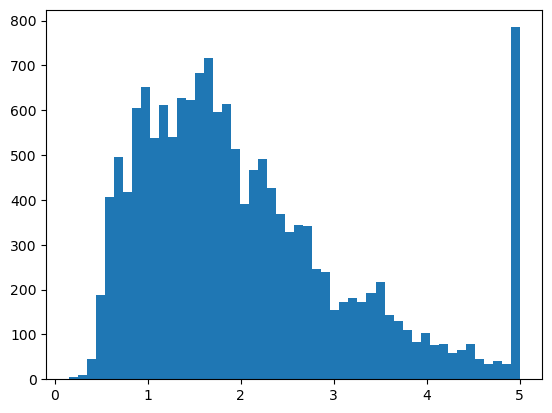

In [97]:
plt.hist(y_train, bins=50)


In [1]:
print"just to change"

<function print(*args, sep=' ', end='\n', file=None, flush=False)>